In [1]:
# 1. Import Library
import os
import yaml
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt

from pathlib import Path
from xgboost import XGBRegressor

In [2]:
# 2. Import Function
sys.path.append(os.path.abspath("../.."))

from src.data_preparation import (
    remove_duplicates,
    remove_same_ohlc_rows
)

from src.features_simulation import (
    add_decision_column,
    filter_decision_positive,
    add_growth_balance,
    add_total_pnl_pct
)

In [3]:
# 3. Load Parameter
with open("../../config/parameter.yaml", "r") as f:
    parameter_config = yaml.safe_load(f)

features_parameter = parameter_config["features_parameter"]
simulation_parameter = parameter_config["simulation_parameter"]
columns_parameter = parameter_config["columns_parameter"]

round_digits = features_parameter["round_digits"]
balance = simulation_parameter["balance"]

raw_to_drop = columns_parameter["raw_to_drop"]
columns_to_drop = columns_parameter["columns_to_drop"]

all_columns_to_drop = raw_to_drop + columns_to_drop

print(f"round_digits    : {round_digits}")
print(f"balance         : {balance}")
print(f"raw_to_drop     : {raw_to_drop}")
print(f"columns_to_drop : {columns_to_drop}")

round_digits    : 6
balance         : 10000000
raw_to_drop     : ['open', 'high', 'low', 'close', 'adj_close', 'volume']
columns_to_drop : ['close_vwap_21_ratio', 'z_score_return_21', 'volume_spike_ratio', 'bb_pct_b', 'z_score_gk_var_21_rank_pct']


In [4]:
# 4. Load Data
with open("../../config/paths.yaml", "r") as f:
    paths_config = yaml.safe_load(f)

preparation_data_path = paths_config["data"]["05_data_preparation"]

csv_file_path_train = os.path.join(preparation_data_path, "01_train_prep_technicals.csv")
csv_file_path_val = os.path.join(preparation_data_path, "02_val_prep_technicals.csv")
csv_file_path_simulation = os.path.join(preparation_data_path, "simulation_data.csv")
csv_file_path_val_index = os.path.join(preparation_data_path, "02_val_prep_technicals_index.csv")
csv_file_path_test_index = os.path.join(preparation_data_path, "03_test_prep_technicals_index.csv")

df_data_train = pd.read_csv(csv_file_path_train, parse_dates=["date"])
df_data_val = pd.read_csv(csv_file_path_val, parse_dates=["date"])
df_data_simulation = pd.read_csv(csv_file_path_simulation, parse_dates=["date"])
df_data_train_ready = pd.concat([df_data_train, df_data_val], ignore_index=True)
df_data_train_ready = df_data_train_ready.sort_values(by=['ticker', 'date']).reset_index(drop=True)
df_data_train_ready = remove_duplicates(df_data_train_ready)
df_data_train_ready = remove_same_ohlc_rows(df_data_train_ready)
df_data_val_index = pd.read_csv(csv_file_path_val_index, parse_dates=["date"])
df_data_test_index = pd.read_csv(csv_file_path_test_index, parse_dates=["date"])

df_data_train.drop(columns=all_columns_to_drop, inplace=True)
df_data_val.drop(columns=all_columns_to_drop, inplace=True)
df_data_simulation.drop(columns=all_columns_to_drop, inplace=True)
df_data_train_ready.drop(columns=all_columns_to_drop, inplace=True)

print("df_data_train shape       :", df_data_train.shape)
print("df_data_val shape         :", df_data_val.shape)
print("df_data_simulation shape  :", df_data_simulation.shape)
print("df_data_train_ready shape :", df_data_train_ready.shape)
print("df_data_val_index shape   :", df_data_val_index.shape)
print("df_data_test_index shape  :", df_data_test_index.shape)

df_data_train shape       : (67853, 39)
df_data_val shape         : (18420, 39)
df_data_simulation shape  : (18657, 40)
df_data_train_ready shape : (86000, 39)
df_data_val_index shape   : (726, 8)
df_data_test_index shape  : (724, 8)


In [5]:
# 5. Splitting Features & Label
target = "rank_pct"

feature_cols = df_data_train_ready.select_dtypes(include=[np.number]).columns.tolist()
if target in feature_cols:
    feature_cols.remove(target)

X_train = df_data_train_ready[feature_cols]
y_train = df_data_train_ready[target]

X_test = df_data_simulation[feature_cols]
y_test = df_data_simulation[target]

print("Total features :", len(feature_cols))

Total features : 36


In [6]:
# 6. Hyperparameter Tuning & Train Model
param_dist = {
    "subsample": 0.7,
    "reg_lambda": 0.1,
    "reg_alpha": 0.1,
    "n_estimators": 800,
    "max_depth": 6,
    "learning_rate": 0.01,
    "gamma": 0.1,
    "colsample_bytree": 1.0
}

model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    **param_dist
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [7]:
# 7. Predict
df_data_simulation["rank_pct_predicted"] = (model.predict(X_test).astype("float64"))

df_data_predicted = df_data_simulation[[
    "ticker",
    "date",
    "next_close_pct",
    "rank_pct",
    "rank_pct_predicted"
]]

df_data_ihsg = df_data_test_index.loc[
    df_data_test_index["ticker"] == "^JKSE",
    ["ticker", "date", "close"]
].reset_index(drop=True)

df_data_gold = df_data_test_index.loc[
    df_data_test_index["ticker"] == "GC=F",
    ["ticker", "date", "close"]
].reset_index(drop=True)

df_data_lq_45 = df_data_test_index.loc[
    df_data_test_index["ticker"] == "^JKLQ45",
    ["ticker", "date", "close"]
].reset_index(drop=True)

In [8]:
# 8. Features Engineering
df_data_predicted = add_decision_column(df_data_predicted)
df_data_predicted = filter_decision_positive(df_data_predicted)
df_data_predicted = add_growth_balance(df_data_predicted, balance)
df_data_predicted = add_total_pnl_pct(
    df_data_predicted, 
    "2025-01-02",
    "balance",
    round_digits
)

df_data_ihsg = add_total_pnl_pct(
    df_data_ihsg, 
    "2025-01-02",
    "close",
    round_digits
)
df_data_gold = add_total_pnl_pct(
    df_data_gold, 
    "2025-01-02",
    "close",
    round_digits
)
df_data_lq_45 = add_total_pnl_pct(
    df_data_lq_45, 
    "2025-01-02",
    "close",
    round_digits
)

In [9]:
# 9. Export to CSV
with open("../../config/paths.yaml", "r") as f:
    paths_config = yaml.safe_load(f)

simulation_data_path = Path(paths_config["data"]["06_data_simulation"])
simulation_data_path.mkdir(parents=True, exist_ok=True)

output_file_predicted = simulation_data_path / "data_predicted.csv"
output_file_ihsg = simulation_data_path / "data_ihsg.csv"
output_file_gold = simulation_data_path / "data_gold.csv"
output_file_lq_45 = simulation_data_path / "data_lq_45.csv"

df_data_predicted.to_csv(output_file_predicted, index=False)
df_data_ihsg.to_csv(output_file_ihsg, index=False)
df_data_gold.to_csv(output_file_gold, index=False)
df_data_lq_45.to_csv(output_file_lq_45, index=False)

print(f"Data predicted berhasil disimpan ke : '{output_file_predicted}'")
print(f"Data ihsg berhasil disimpan ke      : '{output_file_ihsg}'")
print(f"Data gold berhasil disimpan ke      : '{output_file_gold}'")
print(f"Data lq_45 berhasil disimpan ke     : '{output_file_lq_45}'")

print(f"Total baris data predicted          : {len(df_data_predicted):,}")
print(f"Total baris data ihsg               : {len(df_data_ihsg):,}")
print(f"Total baris data gold               : {len(df_data_gold):,}")
print(f"Total baris data lq_45              : {len(df_data_lq_45):,}")

Data predicted berhasil disimpan ke : '..\..\data\06_data_simulation\data_predicted.csv'
Data ihsg berhasil disimpan ke      : '..\..\data\06_data_simulation\data_ihsg.csv'
Data gold berhasil disimpan ke      : '..\..\data\06_data_simulation\data_gold.csv'
Data lq_45 berhasil disimpan ke     : '..\..\data\06_data_simulation\data_lq_45.csv'
Total baris data predicted          : 1,180
Total baris data ihsg               : 236
Total baris data gold               : 252
Total baris data lq_45              : 236


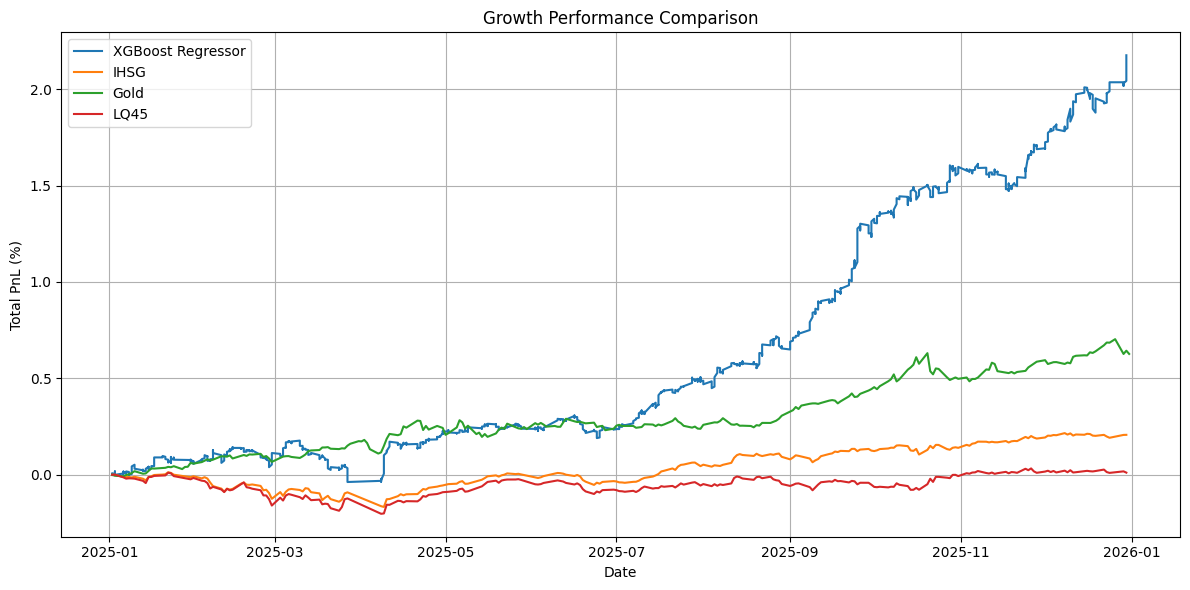

In [10]:
# ------ Balance Growth Plot ------
plt.figure(figsize=(12, 6))
plt.plot(df_data_predicted["date"], df_data_predicted["total_pnl_pct"], label="XGBoost Regressor")
plt.plot(df_data_ihsg["date"], df_data_ihsg["total_pnl_pct"], label="IHSG")
plt.plot(df_data_gold["date"], df_data_gold["total_pnl_pct"], label="Gold")
plt.plot(df_data_lq_45["date"], df_data_lq_45["total_pnl_pct"], label="LQ45")

plt.xlabel("Date")
plt.ylabel("Total PnL (%)")
plt.title("Growth Performance Comparison")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [11]:
df_data_predicted.head(9999999)

,ticker,date,next_close_pct,rank_pct,rank_pct_predicted,decision,balance,total_pnl_pct
17005,SSIA.JK,2025-01-02,-0.013393,0.2750,0.778119,1,9973214.0,0.000000
7803,EXCL.JK,2025-01-02,-0.008889,0.3875,0.550780,1,9955484.0,-0.001778
15,ACES.JK,2025-01-02,0.000000,0.6438,0.538650,1,9955484.0,-0.001778
12051,MBMA.JK,2025-01-02,0.000000,0.6438,0.535054,1,9955484.0,-0.001778
15119,PTRO.JK,2025-01-02,0.049180,0.9625,0.533863,1,10053406.0,0.008041
...,...,...,...,...,...,...,...,...
18420,UNTR.JK,2025-12-30,0.020339,0.7375,0.571765,1,30348756.0,2.043027
18656,UNVR.JK,2025-12-30,0.007692,0.5375,0.562833,1,30395444.0,2.047708
10870,JPFA.JK,2025-12-30,0.106870,1.0000,0.551666,1,31045117.0,2.112850
13230,MNCN.JK,2025-12-30,0.022901,0.7625,0.544550,1,31187309.0,2.127107


In [12]:
df_data_predicted.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1180 entries, 17005 to 8274
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ticker              1180 non-null   object        
 1   date                1180 non-null   datetime64[ns]
 2   next_close_pct      1180 non-null   float64       
 3   rank_pct            1180 non-null   float64       
 4   rank_pct_predicted  1180 non-null   float64       
 5   decision            1180 non-null   Int32         
 6   balance             1180 non-null   float64       
 7   total_pnl_pct       1180 non-null   float64       
dtypes: Int32(1), datetime64[ns](1), float64(5), object(1)
memory usage: 79.5+ KB
